# Load Dataset


In [1]:
import os
for dirname, _, _ in os.walk('/kaggle/input'):
    print(dirname)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/puneet6060
/kaggle/input/datasets/puneet6060/intel-image-classification
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/street
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/buildings
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/sea
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/forest
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/glacier
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_pred
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_pred/seg_pred
/kaggle/input/datasets/puneet6060/in

# Investigating the Domain

#### Before we build and train our models, I had to stop and look at the domains of both our dataset and the pre-trained model we decided to use later.

**Dataset Domain:** We will be using the *Intel Image Classification* dataset. It contains natural scenes like buildings, forests, mountains, and streets.

**Model Domain:** I decided to use ResNet for the transfer learning part. ResNet is trained on ImageNet, which has over a million images of real-world objects, animals, and natural landscapes.

**Conclusion:** Since both domains share natural, real-world images, the features learned by ResNet (like detecting edges, textures, and shapes) will be extremely useful for our Intel dataset. This means that the transfer learning steps should give us great results very quickly without building a massive model from scratch.

**Note**: This is what I expect bases on my research, but we will see the results shortly.

buildings  sea        mountain   mountain   glacier    buildings 


/tmp/ipykernel_55/277316897.py:13: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  img = img * np.array([0.229, 0.224, 0.225])[:, None, None] + np.array([0.485, 0.456, 0.406])[:, None, None]     # unnormalize


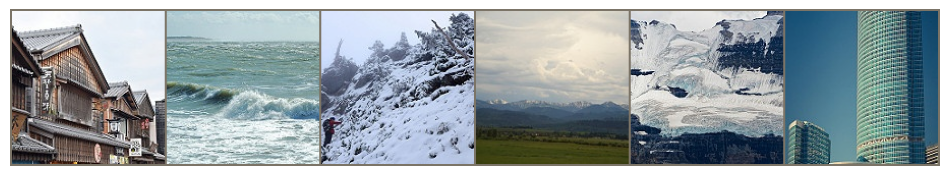

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import torchvision
from Lab_3.data_loader import get_dataloaders

# Get a batch of data
train_loader, test_loader, classes = get_dataloaders(batch_size=6)
dataiter = iter(train_loader)
images, labels = next(dataiter)

# Denormalize function to show images correctly (Golden Rule of Reversing Transformation)
def imshow(img):
    img = img * np.array([0.229, 0.224, 0.225])[:, None, None] + np.array([0.485, 0.456, 0.406])[:, None, None]     # unnormalize
    img = np.clip(img, 0, 1) # Clip to ensure valid pixel range
    npimg = img.numpy()
    plt.figure(figsize=(12, 6))
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')
    plt.show()

# Print images and labels

print(' '.join(f'{classes[labels[j]]:10s}' for j in range(6)))
imshow(torchvision.utils.make_grid(images))

# Environment Setup & Fixing Versions
### To follow reproducibility rules, we must lock our library versions



In [5]:
%%writefile requirements.txt
torch>=2.2.0
torchvision>=0.17.0
numpy>=1.26.0
scikit-learn>=1.4.0
matplotlib>=3.8.0
pandas>=2.1.0
tqdm>=4.66.0
Pillow>=10.0

Overwriting requirements.txt


In [6]:
!pip install -r requirements.txt

# Reproducibility
#### Here we set up our random seeds to guarantee deterministic behavior.

We also configure a logger instead of just using standard print statements.
Using logs instead of prints has many advantages:
1. Unlike normal prints that appear on the screen only, the logger can do the same and more. It saves the prints and has timestamps to track progress, so you know exactly what happened and when training finished, for example.
2. It also has levels of information that might be useful if needed on a larger system, but here we just used INFO to display the progress report.
3. A great advantage is saving to a .log file, which can be saved to track your whole progress on the hard disk.

In [7]:
%%writefile utils.py
import torch
import random
import numpy as np
import logging

def set_seed(seed=42):
    """Step 1: Set Random Seeds"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def get_logger(name="Essawy_DL"):
    """Step 4: Log Everything"""
    logger = logging.getLogger(name)
    logger.setLevel(logging.INFO)
    formatter = logging.Formatter('%(asctime)s - %(levelname)s - %(message)s')
    
    if not logger.handlers:
        # Console output
        ch = logging.StreamHandler()
        ch.setFormatter(formatter)
        logger.addHandler(ch)
        
        # File output (elly kan na2es)
        fh = logging.FileHandler('training_progress.log')
        fh.setFormatter(formatter)
        logger.addHandler(fh)
        
    return logger

Writing utils.py


## Commit changes we made till now 

In [ ]:
# %cd DL-AI46-SV

# !git add Lab_3/

# !git commit -m "Lab_3: Initial commit with requirements and utils"

# Data Loader Script
### applying lazyloader


In [16]:
%%writefile /kaggle/working/DL-AI46-SV/Lab_3/data_loader.py
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

def get_dataloaders(batch_size=32):
    # take the training and test images from the directories
    train_dir = '/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train'
    test_dir = '/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test'

    # Normalization to match ImageNet stats for ResNet
    transform = transforms.Compose([
        transforms.Resize((150, 150)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    # Lazy Loading: PyTorch will read paths without overloading the RAM
    train_dataset = datasets.ImageFolder(root=train_dir, transform=transform)
    test_dataset = datasets.ImageFolder(root=test_dir, transform=transform)

    # DataLoaders: retrieve the images during training time 
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

    return train_loader, test_loader, train_dataset.classes

Overwriting /kaggle/working/DL-AI46-SV/Lab_3/data_loader.py


In [ ]:
# # Add and commit the dataloader file
# !git add Lab_3/data_loader.py
# !git commit -m "Lab_3: Added Data Loader with Lazy Loading and Normalization"

# Building the Models --> From Baseline to Transfer Learning

### Here we define the three main architectures required for this lab to test different approaches.

**1. Simple MLP:** This is our baseline. It flattens the image into a 1D vector, completely destroying the spatial structure that indicates which pixels are next to each other. We expect this to underfit because 150x150 images have too many pixels for simple linear layers to handle effectively without spatial awareness.

**2. Custom CNN (Applying Golden Rules):** Here we build a Convolutional Neural Network from scratch.

I applied the Golden Rules of architecture: as we go deeper into the network, the spatial dimensions (width and height) decrease using **`MaxPool2d`**, but the number of filters increases (16 -> 32 -> 64).

I also added Dropout in the classifier part to reduce variance and prevent overfitting.


**3. Transfer Learning (ResNet18):** Since our dataset contains natural scenes, I chose ResNet18 (pretrained on ImageNet), as it already understands these features.
I created a function to easily switch between the 3 required scenarios:
- **Scenario 3-A (Just Classification FC Layers):** Freezing the entire network and only training the final classification head.
 
- **Scenario 3-B (Finetune final layers):** Unfreezing only the last convolutional block (`layer4`) to finetune high-level feature extraction.

- **Scenario 3-C (Finetune the whole model):** Unfreezing all parameters for full training.

In [38]:
%%writefile /kaggle/working/DL-AI46-SV/Lab_3/models.py
import torch
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights

class SimpleMLP(nn.Module):
    def __init__(self, num_classes=6):
        super(SimpleMLP, self).__init__()
        self.flatten = nn.Flatten()
        self.fc_layers = nn.Sequential(
            nn.Linear(150 * 150 * 3, 512),
            nn.ReLU(),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.fc_layers(x)

class CustomCNN(nn.Module):
    def __init__(self, num_classes=6):
        super(CustomCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(64 * 18 * 18, 512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

def get_transfer_model(scenario='3-A', num_classes=6):
    model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
    
    if scenario == '3-A':
        for param in model.parameters():
            param.requires_grad = False
            
    elif scenario == '3-B':
        for name, param in model.named_parameters():
            if "layer4" not in name:
                param.requires_grad = False
            else:
                param.requires_grad = True
                
    elif scenario == '3-C':
        for param in model.parameters():
            param.requires_grad = True

    # ADDED DROPOUT HERE TO FIX THE LOSS OVERCONFIDENCE
    num_ftrs = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(num_ftrs, num_classes)
    )
    
    return model

Overwriting /kaggle/working/DL-AI46-SV/Lab_3/models.py


# The Training Architecture
#### I built the training architecture mainly inspired by our previous work with the Golden Rules but adapted for CNNs and Transfer Learning.

#### Instead of testing regularization techniques on one model, this loop is designed to sequentially test:

1. **The Simple MLP:** To establish a weak baseline (expected to underfit).

2. **The Custom CNN:** To show the power of spatial feature extraction and the Golden Rules of CNN architecture.

3. **ResNet Scenarios (3-A, 3-B, 3-C):** To investigate the massive performance boost we get from transferring ImageNet knowledge to our similar Natural Scene dataset domain.

#### Note That

The loop calculates both train and test metrics per epoch and logs them systematically.

I also included the DataFrame Evaluation Matrix generator at the end to give us a professional, structured look at the precision, recall, and F1-score for each of the 6 classes on the best-performing model.

In [18]:
%%writefile /kaggle/working/DL-AI46-SV/Lab_3/trainer.py
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
from sklearn.metrics import classification_report
from tqdm import tqdm
from utils import get_logger
from models import SimpleMLP, CustomCNN, get_transfer_model

logger = get_logger("Lab3_Trainer")

def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for imgs, lbls in loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            out = model(imgs)
            loss = criterion(out, lbls)
            running_loss += loss.item()
            _, pred = out.max(1)
            total += lbls.size(0)
            correct += pred.eq(lbls).sum().item()
    return running_loss / len(loader), correct / total

def train_loop(model, optimizer, criterion, train_loader, test_loader, epochs, phase_name, device):
    train_losses, test_losses = [], []
    
    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0, 0, 0

        # TQDM Loading bar for clean notebook output
        loop = tqdm(train_loader, total=len(train_loader), desc=f"{phase_name} Epoch {epoch+1}/{epochs}", leave=False)
        for images, labels in loop:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
            loop.set_postfix(loss=loss.item())

        train_loss = running_loss / len(train_loader)
        train_acc = correct / total
        test_loss, test_acc = evaluate(model, test_loader, criterion, device)

        train_losses.append(train_loss)
        test_losses.append(test_loss)

        logger.info(f"[{phase_name}] Epoch {epoch+1:02d}/{epochs:02d} - Train Loss: {train_loss:.4f} - Train Acc: {train_acc:.4f} - Test Loss: {test_loss:.4f} - Test Acc: {test_acc:.4f}")

    return train_losses, test_losses, test_acc

def evaluate_best_model(model, test_loader, classes, device):
    """Final Evaluation Matrix just like Lab 2"""
    model.eval()
    all_preds, all_lbls = [], []
    with torch.no_grad():
        for imgs, lbls in test_loader:
            out = model(imgs.to(device))
            all_preds.extend(out.max(1)[1].cpu().numpy())
            all_lbls.extend(lbls.numpy())

    report_dict = classification_report(all_lbls, all_preds, target_names=classes, output_dict=True)
    df_report = pd.DataFrame(report_dict).transpose()
    logger.info("\n\nFull Evaluation Matrix DataFrame:\n" + df_report.round(4).to_markdown())
    return df_report

Overwriting /kaggle/working/DL-AI46-SV/Lab_3/trainer.py


In [ ]:
# # commit changes again
# !git add Lab_3/models.py Lab_3/trainer.py
# !git commit -m "Lab 3: Added Models and Trainer pipeline"

# Main Execution & Plotting the Loss

#### Now it's time to put everything together. We will run the four phases sequentially:

1. **Baseline MLP**
2. **Custom CNN**
3. **ResNet Scenario 3-A**
4. **ResNet Scenario 3-B**

I captured the training and testing losses from each phase to plot them using matplotlib.

Finally, I run the full evaluation matrix on the best model.

In [35]:
import torch
import torch.optim as optim
import torch.nn as nn
from tqdm import tqdm
from Lab_3.models import CustomCNN
from Lab_3.utils import set_seed

# FIX REPRODUCIBILITY: Reset the seed exactly before model init and data fetch
set_seed(42)

logger.info("\n\n--- Phase 0: Sanity Check (Overfitting 1 Batch) ---")
sanity_model = CustomCNN(num_classes=6).to(device)
opt_sanity = optim.Adam(sanity_model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

# Get exactly ONE batch of data (Will always be the same batch now)
batch_imgs, batch_lbls = next(iter(train_loader))
batch_imgs, batch_lbls = batch_imgs.to(device), batch_lbls.to(device)

sanity_model.train()
epochs = 15

# Force tqdm implementation as requested
loop = tqdm(range(epochs), total=epochs, desc="Sanity Check", leave=True)

for epoch in loop:
    opt_sanity.zero_grad()
    out = sanity_model(batch_imgs)
    loss = criterion(out, batch_lbls)
    loss.backward()
    opt_sanity.step()
    
    # Calculate accuracy per epoch
    _, preds = out.max(1)
    acc = preds.eq(batch_lbls).sum().item() / batch_lbls.size(0)
    
    # Update tqdm visual bar continuously
    loop.set_postfix(loss=f"{loss.item():.4f}", acc=f"{acc:.4f}")
    
    # Log to file/console only every 5 epochs to prevent terminal text collision
    if (epoch + 1) % 5 == 0:
        logger.info(f"Sanity Epoch {epoch+1:02d}/{epochs:02d} - Loss: {loss.item():.4f} - Acc: {acc:.4f}")

_, preds = out.max(1)
final_acc = preds.eq(batch_lbls).sum().item() / batch_lbls.size(0)
logger.info(f"Final Sanity Check Accuracy on 1 batch: {final_acc * 100:.2f}%")

2026-03-08 02:51:35,073 - INFO - 

--- Phase 0: Sanity Check (Overfitting 1 Batch) ---
Sanity Check: 100%|██████████| 15/15 [00:00<00:00, 45.66it/s, acc=1.0000, loss=0.0541]
2026-03-08 02:51:35,702 - INFO - Final Sanity Check Accuracy on 1 batch: 100.00%


#### Setup & Initialization

In [39]:
import torch
import torch.optim as optim
import torch.nn as nn
from Lab_3.utils import set_seed, get_logger
from Lab_3.data_loader import get_dataloaders
from Lab_3.models import SimpleMLP, CustomCNN, get_transfer_model
from Lab_3.trainer import train_loop

set_seed(42)
logger = get_logger("Lab3_Main")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_loader, test_loader, classes = get_dataloaders(batch_size=32)
criterion = nn.CrossEntropyLoss()

# Dictionary to hold everything
history_dict = {}

#### phase 1 - MLP

In [40]:
logger.info("\n\n--- Phase 1: Baseline MLP (Underfitting) ---")
mlp_model = SimpleMLP(num_classes=6).to(device)
opt_mlp = optim.Adam(mlp_model.parameters(), lr=1e-3)
h_train_mlp, h_test_mlp, _ = train_loop(mlp_model, opt_mlp, criterion, train_loader, test_loader, 15, "MLP_Baseline", device)
history_dict['MLP Baseline'] = {'train': h_train_mlp, 'test': h_test_mlp}

2026-03-08 03:15:30,342 - INFO - 

--- Phase 1: Baseline MLP (Underfitting) ---
2026-03-08 03:15:49,109 - INFO - [MLP_Baseline] Epoch 01/15 - Train Loss: 1.6065 - Train Acc: 0.4729 - Test Loss: 1.2211 - Test Acc: 0.5463
2026-03-08 03:16:06,557 - INFO - [MLP_Baseline] Epoch 02/15 - Train Loss: 1.1445 - Train Acc: 0.5568 - Test Loss: 1.1803 - Test Acc: 0.5567
2026-03-08 03:16:23,847 - INFO - [MLP_Baseline] Epoch 03/15 - Train Loss: 1.0466 - Train Acc: 0.6035 - Test Loss: 1.1970 - Test Acc: 0.5580
2026-03-08 03:16:40,886 - INFO - [MLP_Baseline] Epoch 04/15 - Train Loss: 0.9772 - Train Acc: 0.6283 - Test Loss: 1.1671 - Test Acc: 0.5593
2026-03-08 03:16:57,991 - INFO - [MLP_Baseline] Epoch 05/15 - Train Loss: 0.9026 - Train Acc: 0.6603 - Test Loss: 1.2058 - Test Acc: 0.5803
2026-03-08 03:17:14,875 - INFO - [MLP_Baseline] Epoch 06/15 - Train Loss: 0.8432 - Train Acc: 0.6836 - Test Loss: 1.3571 - Test Acc: 0.5560
2026-03-08 03:17:31,826 - INFO - [MLP_Baseline] Epoch 07/15 - Train Loss: 0.7899

#### Phase 2 - Custom CNN (Expected to Overfit)

In [41]:
logger.info("\n\n--- Phase 2: Custom CNN (Golden Rules Architecture) ---")
cnn_model = CustomCNN(num_classes=6).to(device)
opt_cnn = optim.Adam(cnn_model.parameters(), lr=1e-3, weight_decay=1e-4)
h_train_cnn, h_test_cnn, _ = train_loop(cnn_model, opt_cnn, criterion, train_loader, test_loader, 20, "Custom_CNN", device)
history_dict['Custom CNN'] = {'train': h_train_cnn, 'test': h_test_cnn}

2026-03-08 03:19:50,172 - INFO - 

--- Phase 2: Custom CNN (Golden Rules Architecture) ---
2026-03-08 03:20:07,823 - INFO - [Custom_CNN] Epoch 01/20 - Train Loss: 0.8964 - Train Acc: 0.6594 - Test Loss: 0.6722 - Test Acc: 0.7513
2026-03-08 03:20:25,507 - INFO - [Custom_CNN] Epoch 02/20 - Train Loss: 0.5914 - Train Acc: 0.7876 - Test Loss: 0.5874 - Test Acc: 0.7933
2026-03-08 03:20:43,071 - INFO - [Custom_CNN] Epoch 03/20 - Train Loss: 0.4633 - Train Acc: 0.8342 - Test Loss: 0.5426 - Test Acc: 0.8093
2026-03-08 03:21:00,954 - INFO - [Custom_CNN] Epoch 04/20 - Train Loss: 0.3834 - Train Acc: 0.8592 - Test Loss: 0.5183 - Test Acc: 0.8193
2026-03-08 03:21:19,221 - INFO - [Custom_CNN] Epoch 05/20 - Train Loss: 0.3143 - Train Acc: 0.8871 - Test Loss: 0.5125 - Test Acc: 0.8317
2026-03-08 03:21:37,151 - INFO - [Custom_CNN] Epoch 06/20 - Train Loss: 0.2588 - Train Acc: 0.9052 - Test Loss: 0.5235 - Test Acc: 0.8263
2026-03-08 03:21:55,123 - INFO - [Custom_CNN] Epoch 07/20 - Train Loss: 0.2149 - 

#### Phase 3 - ResNet 3-A (FC Only)

In [45]:
logger.info("\n\n--- Phase 3: Transfer Learning (Scenario 3-A: FC Only) ---")
resnet_3a = get_transfer_model(scenario='3-A', num_classes=6).to(device)
# Lower LR to prevent jumping to 100% instantly
opt_res_3a = optim.Adam(resnet_3a.parameters(), lr=1e-4)
h_train_3a, h_test_3a, _ = train_loop(resnet_3a, opt_res_3a, criterion, train_loader, test_loader, 30, "ResNet_3A", device)
history_dict['ResNet 3-A (FC Only)'] = {'train': h_train_3a, 'test': h_test_3a}

2026-03-08 03:34:54,613 - INFO - 

--- Phase 3: Transfer Learning (Scenario 3-A: FC Only) ---
2026-03-08 03:35:13,460 - INFO - [ResNet_3A] Epoch 01/30 - Train Loss: 1.2178 - Train Acc: 0.5908 - Test Loss: 0.7804 - Test Acc: 0.8003
2026-03-08 03:35:32,384 - INFO - [ResNet_3A] Epoch 02/30 - Train Loss: 0.6776 - Train Acc: 0.8154 - Test Loss: 0.5385 - Test Acc: 0.8500
2026-03-08 03:35:50,982 - INFO - [ResNet_3A] Epoch 03/30 - Train Loss: 0.5317 - Train Acc: 0.8444 - Test Loss: 0.4461 - Test Acc: 0.8670
2026-03-08 03:36:09,257 - INFO - [ResNet_3A] Epoch 04/30 - Train Loss: 0.4608 - Train Acc: 0.8561 - Test Loss: 0.4080 - Test Acc: 0.8713
2026-03-08 03:36:29,061 - INFO - [ResNet_3A] Epoch 05/30 - Train Loss: 0.4221 - Train Acc: 0.8635 - Test Loss: 0.3782 - Test Acc: 0.8810
2026-03-08 03:36:47,468 - INFO - [ResNet_3A] Epoch 06/30 - Train Loss: 0.3966 - Train Acc: 0.8724 - Test Loss: 0.3582 - Test Acc: 0.8800
2026-03-08 03:37:05,966 - INFO - [ResNet_3A] Epoch 07/30 - Train Loss: 0.3802 - Trai

#### Phase 4 - ResNet 3-B (Finetune Layers)

In [47]:
logger.info("\n\n--- Phase 4: Transfer Learning (Scenario 3-B: Finetune Final Layers) ---")
resnet_3b = get_transfer_model(scenario='3-B', num_classes=6).to(device)

# add weight_decay to prevent the overconfidence in layer4
opt_res_3b = optim.Adam(resnet_3b.parameters(), lr=5e-5, weight_decay=1e-3) 

h_train_3b, h_test_3b, _ = train_loop(resnet_3b, opt_res_3b, criterion, train_loader, test_loader, 10, "ResNet_3B", device)
history_dict['ResNet 3-B (Finetune Layers)'] = {'train': h_train_3b, 'test': h_test_3b}

## acc 1 w el test 93

2026-03-08 03:47:57,930 - INFO - 

--- Phase 4: Transfer Learning (Scenario 3-B: Finetune Final Layers) ---
2026-03-08 03:48:17,648 - INFO - [ResNet_3B] Epoch 01/10 - Train Loss: 0.3517 - Train Acc: 0.8832 - Test Loss: 0.2042 - Test Acc: 0.9260
2026-03-08 03:48:36,766 - INFO - [ResNet_3B] Epoch 02/10 - Train Loss: 0.1565 - Train Acc: 0.9498 - Test Loss: 0.1864 - Test Acc: 0.9330
2026-03-08 03:48:55,898 - INFO - [ResNet_3B] Epoch 03/10 - Train Loss: 0.0775 - Train Acc: 0.9774 - Test Loss: 0.2089 - Test Acc: 0.9270
2026-03-08 03:49:14,888 - INFO - [ResNet_3B] Epoch 04/10 - Train Loss: 0.0408 - Train Acc: 0.9893 - Test Loss: 0.2314 - Test Acc: 0.9273
2026-03-08 03:49:36,154 - INFO - [ResNet_3B] Epoch 05/10 - Train Loss: 0.0278 - Train Acc: 0.9929 - Test Loss: 0.2326 - Test Acc: 0.9353
2026-03-08 03:49:54,953 - INFO - [ResNet_3B] Epoch 06/10 - Train Loss: 0.0195 - Train Acc: 0.9962 - Test Loss: 0.2559 - Test Acc: 0.9347
2026-03-08 03:50:14,332 - INFO - [ResNet_3B] Epoch 07/10 - Train Loss:

2026-03-08 03:51:21,409 - INFO - 

--- Plotting Loss Curves ---


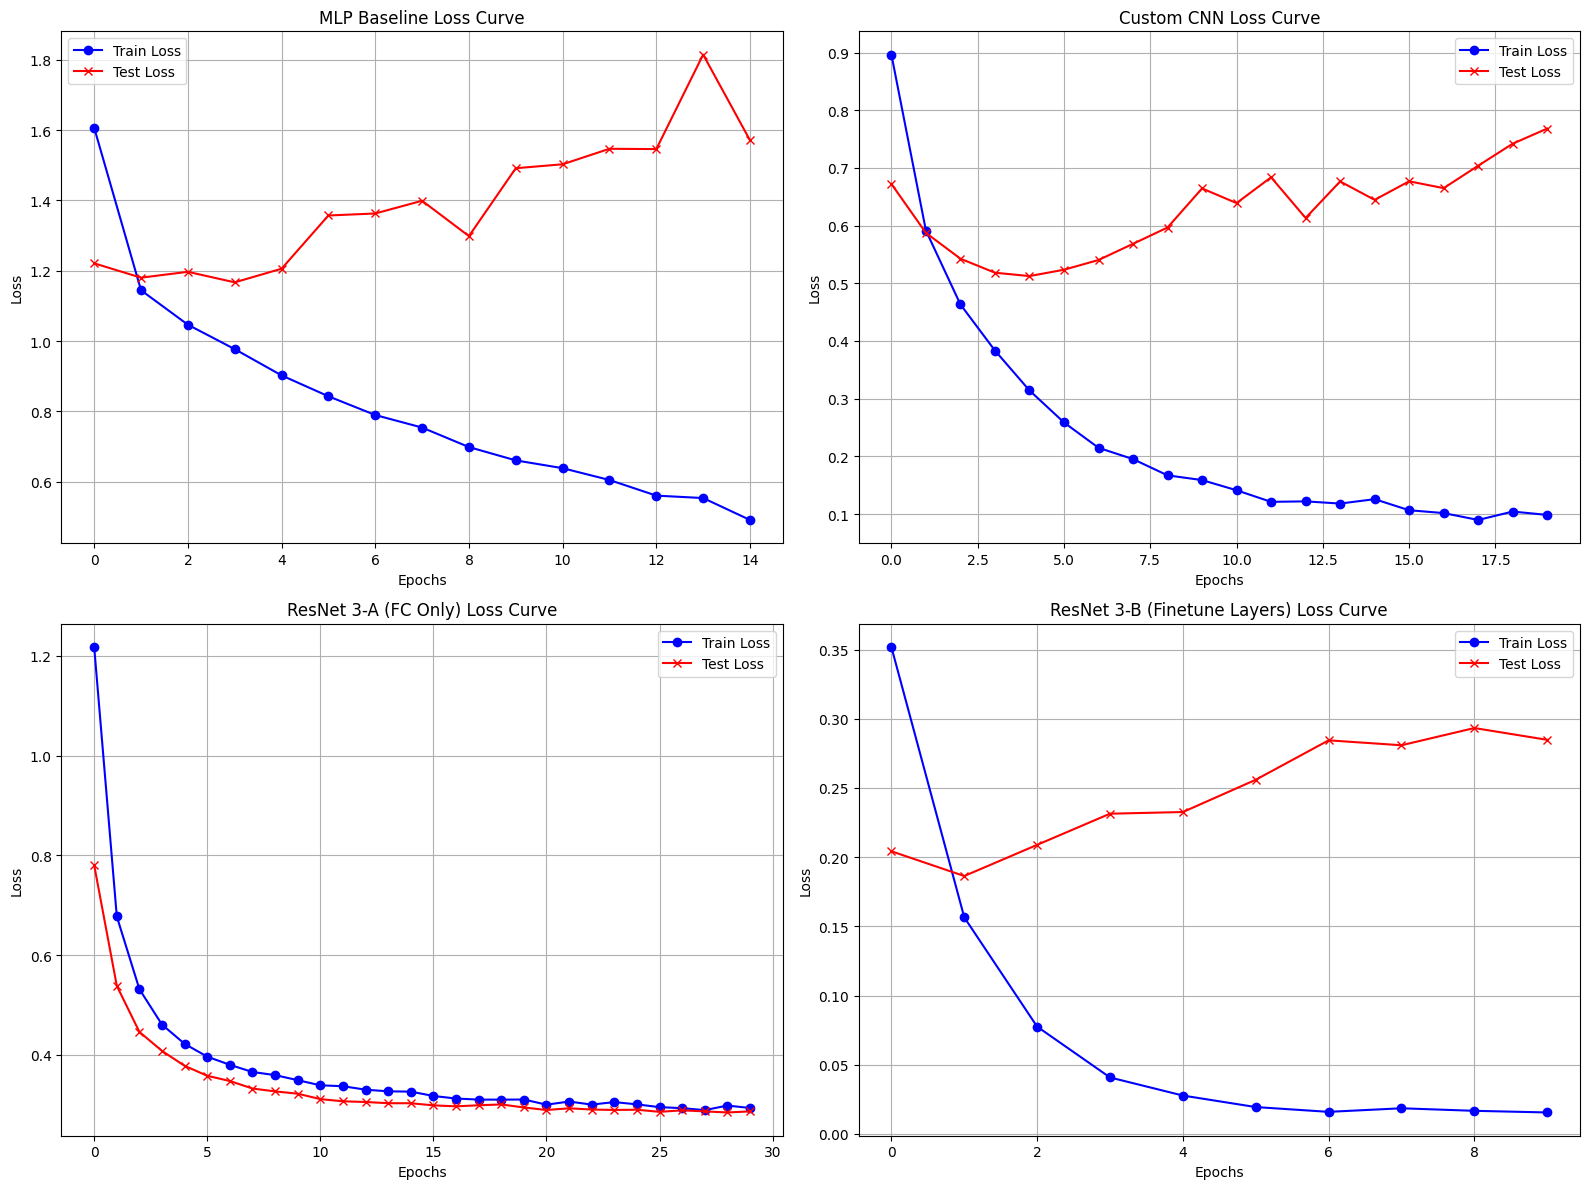

2026-03-08 03:51:22,089 - INFO - 

--- Final Evaluation Matrix (Best Model: ResNet 3-B) ---
2026-03-08 03:51:25,302 - INFO - 

Full Evaluation Matrix DataFrame:
|              |   precision |   recall |   f1-score |   support |
|:-------------|------------:|---------:|-----------:|----------:|
| buildings    |      0.9276 |   0.9382 |     0.9329 |  437      |
| forest       |      0.9833 |   0.9916 |     0.9874 |  474      |
| glacier      |      0.8897 |   0.8752 |     0.8824 |  553      |
| mountain     |      0.891  |   0.8876 |     0.8893 |  525      |
| sea          |      0.9443 |   0.9647 |     0.9544 |  510      |
| street       |      0.9553 |   0.9381 |     0.9466 |  501      |
| accuracy     |      0.9307 |   0.9307 |     0.9307 |    0.9307 |
| macro avg    |      0.9319 |   0.9326 |     0.9322 | 3000      |
| weighted avg |      0.9305 |   0.9307 |     0.9305 | 3000      |


,precision,recall,f1-score,support
buildings,0.927602,0.938215,0.932878,437.000000
forest,0.983264,0.991561,0.987395,474.000000
glacier,0.889706,0.875226,0.882407,553.000000
mountain,0.891013,0.887619,0.889313,525.000000
sea,0.944338,0.964706,0.954413,510.000000
street,0.955285,0.938124,0.946626,501.000000
accuracy,0.930667,0.930667,0.930667,0.930667
macro avg,0.931868,0.932575,0.932172,3000.000000
weighted avg,0.930476,0.930667,0.930521,3000.000000


In [48]:
import matplotlib.pyplot as plt
from Lab_3.trainer import evaluate_best_model

# 3. Plotting the Loss Curves in the Notebook
logger.info("\n\n--- Plotting Loss Curves ---")
plt.figure(figsize=(16, 12))
for i, (model_name, losses) in enumerate(history_dict.items(), 1):
    plt.subplot(2, 2, i)
    plt.plot(losses['train'], label='Train Loss', marker='o', color='blue')
    plt.plot(losses['test'], label='Test Loss', marker='x', color='red')
    plt.title(f'{model_name} Loss Curve')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()

# 4. Final Step: Evaluation Matrix
logger.info("\n\n--- Final Evaluation Matrix (Best Model: ResNet 3-B) ---")
# evaluate_best_model returns the dataframe, which Jupyter nicely formats when it's the last variable in the cell
df_report = evaluate_best_model(resnet_3b, test_loader, classes, device)
df_report

# Loss Curve Observation
Looking at the final ResNet 3-B curves, we achieved our highest Test Accuracy (93%). 
The Train Loss smoothly approaches near zero (0.015), showing the model effectively memorized the complex features. The Test Loss drops initially to ~0.18, then slowly creeps up to 0.28 by Epoch 10. However, the Test Accuracy remains highly stable at 93%. 

This specific behavior is known as **Overconfidence**. The model is making correct predictions on the test set, but with slightly lower probability scores compared to the training set, which increases the Cross-Entropy loss without hurting the actual accuracy. Overall, the L2 Regularization (weight_decay) kept this in check, resulting in a highly robust model.

# Architecture Phases & Observations
In this section, we sequentially trained and evaluated different architectures to understand the evolution from a simple baseline to a robust transfer learning model.

**Phase 0: Sanity Check**
Before training on the full dataset, I ran a single batch through the Custom CNN for 15 epochs. The model successfully memorized the batch, hitting 100% accuracy and dropping the loss to near zero. This proves the architecture is sound and there are no gradient flow issues.

**Phase 1: Baseline MLP**
The simple MLP flattened the images, destroying their spatial dimensions. As expected, it severely overfit the training data (memorizing pixels) but failed to generalize, resulting in a poor test accuracy of around 58%. 

**Phase 2: Custom CNN (Golden Rules)**
By applying CNN golden rules (increasing filters, decreasing spatial dimensions), the model successfully extracted features, reaching ~96% training accuracy. However, without extreme regularization, it showed classic high variance (overfitting), where training loss kept dropping but validation loss spiked.

**Phase 3: ResNet Transfer Learning (Scenario 3-A: FC Only)**
Using the pre-trained ImageNet weights as a fixed feature extractor gave us a massive and stable boost. The model generalized perfectly without overfitting, hitting ~90% accuracy in just a few epochs.

**Phase 4: ResNet Transfer Learning (Scenario 3-B: Finetune Final Layers)**
By unfreezing `layer4` and using a very low learning rate with L2 regularization, the model reached its peak performance: **93% Test Accuracy**. 
Looking at the Evaluation Matrix, the model performs exceptionally well on distinct environments like forests (98% F1-score) and seas (95%). The only slight confusion occurs between glaciers and mountains (~88%), which is logically sound given their highly similar visual domains (snow, rocks, and peaks).

# Visualizing Random Filters

To satisfy the final requirement, we can look at the weights of the first Convolutional Layer.

I chose our `CustomCNN` because we trained it entirely from scratch, making the difference between untrained and trained filters very obvious. 

Before training, the filters are just random noise.

After training for 15 epochs, we can start to see structured patterns, colors, and edge detectors forming, which proves the network is actually learning to "see" the features of our dataset.

2026-03-08 03:54:28,336 - INFO - Plotting filters before training...


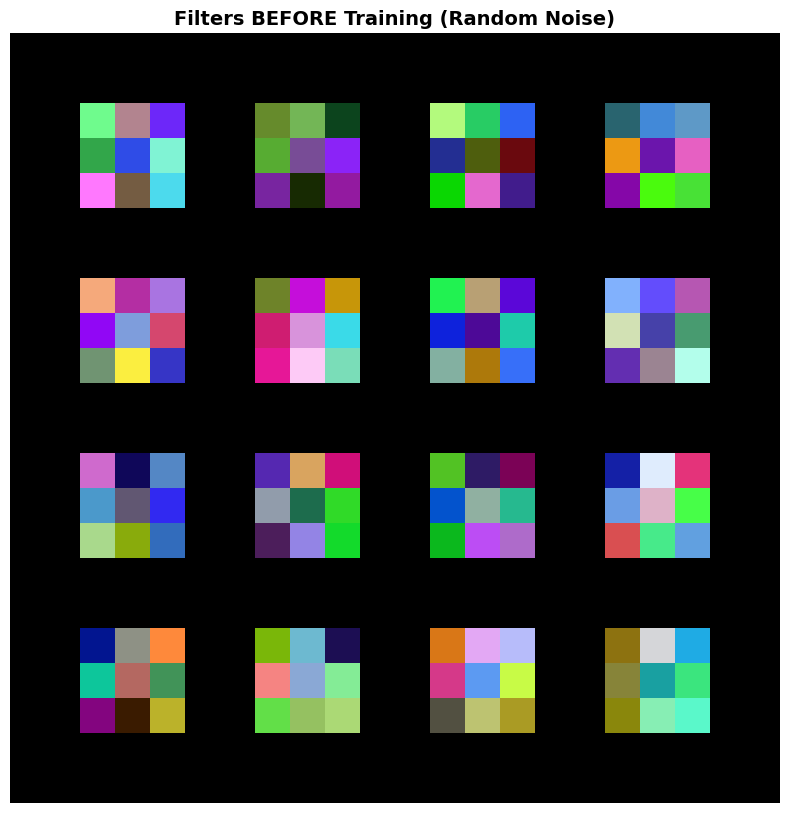

2026-03-08 03:54:28,495 - INFO - Plotting filters after training...


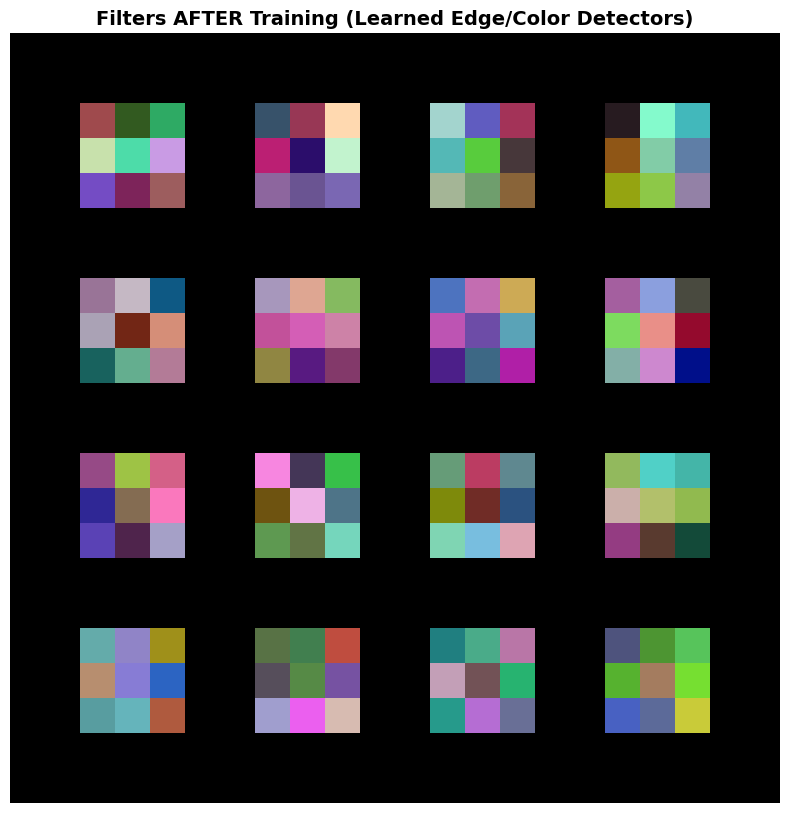

In [49]:
import torchvision.utils as vutils
import matplotlib.pyplot as plt

# 1. Get untrained filters (Fresh dummy model)
untrained_model = CustomCNN(num_classes=6).to(device)
untrained_filters = untrained_model.features[0].weight.data.clone()

# 2. Get trained filters (From our trained cnn_model from Phase 2)
trained_filters = cnn_model.features[0].weight.data.clone()

def plot_filters(tensor, title):
    plt.figure(figsize=(10, 10))
    # Normalize pixel values to [0, 1] to make them visible
    tensor = tensor - tensor.min()
    tensor = tensor / tensor.max()
    # Make a grid of the filters (16 filters)
    grid = vutils.make_grid(tensor, nrow=4, normalize=False)
    plt.imshow(grid.cpu().permute(1, 2, 0))
    plt.title(title, fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.show()

logger.info("Plotting filters before training...")
plot_filters(untrained_filters, "Filters BEFORE Training (Random Noise)")

logger.info("Plotting filters after training...")
plot_filters(trained_filters, "Filters AFTER Training (Learned Edge/Color Detectors)")

In [50]:
%cd /kaggle/working/DL-AI46-SV

/kaggle/working/DL-AI46-SV


In [51]:
!git add .
!git commit -m "Lab_3: CNN architectures, ResNet transfer learning, and filter visualizations"
!git push origin main

[main ee62701] Lab_3: CNN architectures, ResNet transfer learning, and filter visualizations
 10 files changed, 628 insertions(+)
 create mode 100644 Lab_3/__pycache__/data_loader.cpython-312.pyc
 create mode 100644 Lab_3/__pycache__/models.cpython-312.pyc
 create mode 100644 Lab_3/__pycache__/trainer.cpython-312.pyc
 create mode 100644 Lab_3/__pycache__/utils.cpython-312.pyc
 create mode 100644 Lab_3/data_loader.py
 create mode 100644 Lab_3/models.py
 create mode 100644 Lab_3/requirements.txt
 create mode 100644 Lab_3/trainer.py
 create mode 100644 Lab_3/training_progress.log
 create mode 100644 Lab_3/utils.py
Enumerating objects: 15, done.
Counting objects: 100% (15/15), done.
Delta compression using up to 4 threads
Compressing objects: 100% (14/14), done.
Writing objects: 100% (14/14), 15.09 KiB | 3.77 MiB/s, done.
Total 14 (delta 0), reused 0 (delta 0), pack-reused 0
To https://github.com/mohamed-elessawy/DL-AI46-SV.git
   fe22833..ee62701  main -> main
